# 01 — Data sanity check

Run `python -m src.data.pipeline` first, then execute this notebook.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebooks/ or repo root depending on kernel cwd
root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
processed = root / "data" / "processed"
frame = pd.read_parquet(processed / "features_regimes.parquet")
ds = pd.read_parquet(processed / "offline_dataset.parquet")
manifest = json.loads((processed / "dataset_manifest.json").read_text())

print(f"features+regimes: {frame.shape}, dataset transitions: {len(ds):,}")

features+regimes: (4275, 22), dataset transitions: 16,856


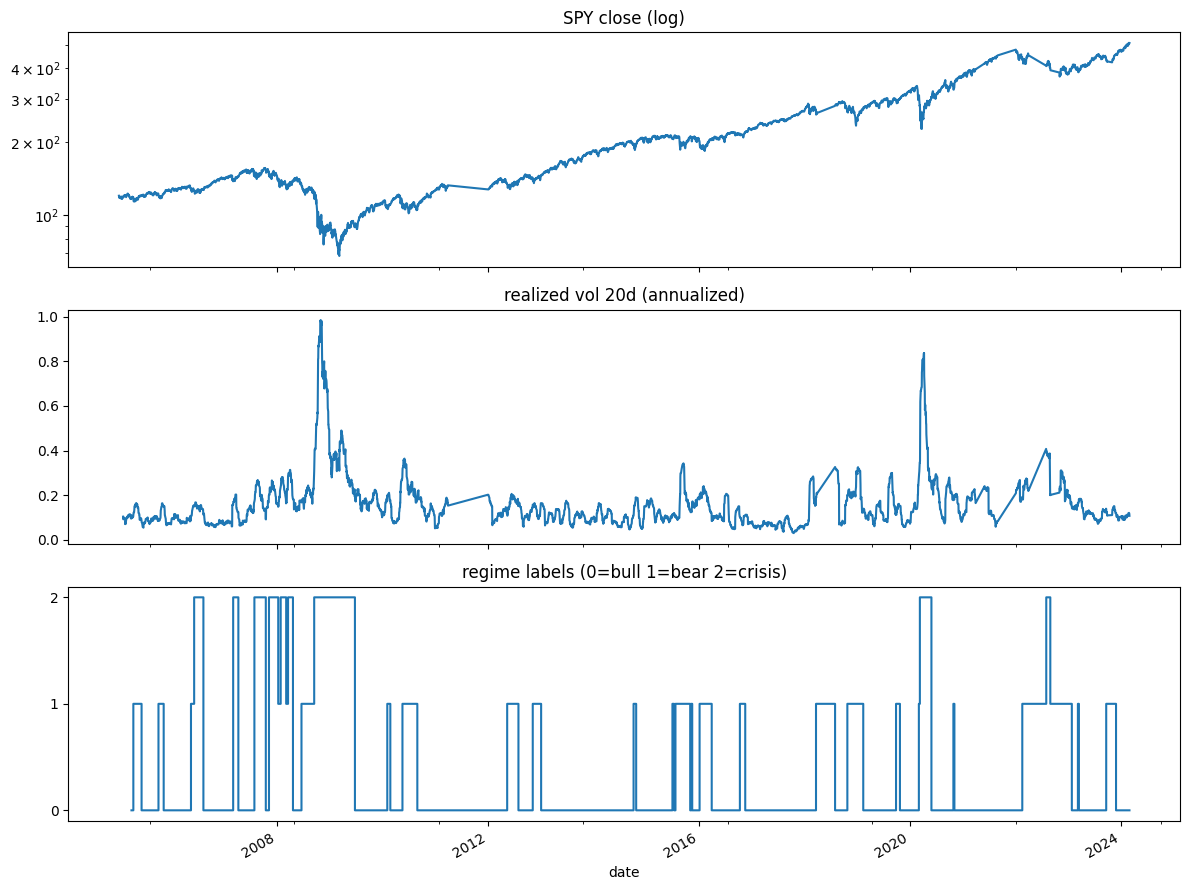

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
frame["close"].plot(ax=axes[0], logy=True, title="SPY close (log)")
frame["realized_vol_20d"].plot(ax=axes[1], title="realized vol 20d (annualized)")
regime_num = frame["regime"].map({"bull": 0, "bear": 1, "crisis": 2})
regime_num.plot(ax=axes[2], drawstyle="steps-post", title="regime labels (0=bull 1=bear 2=crisis)")
axes[2].set_yticks([0, 1, 2])
plt.tight_layout()
plt.show()

In [3]:
print("Regime breakdown (days):")
for regime, cnt in manifest["regime_counts_days"].items():
    print(f"  {regime:<8} {cnt:>6,}")

print("\nPolicy action stats:")
print(pd.DataFrame(manifest["policies"]).T.round(4))

Regime breakdown (days):
  bear        748
  bull      2,976
  crisis      490

Policy action stats:
                     n  share  action_mean  action_std  action_min  \
buy_and_hold    4214.0   0.25       1.0000      0.0000      1.0000   
mean_reversion  4214.0   0.25      -0.2012      0.9757     -1.0000   
momentum        4214.0   0.25       0.3122      0.9467     -1.0000   
random          4214.0   0.25       0.0111      0.5708     -0.9994   

                action_max  reward_mean  
buy_and_hold        1.0000       0.0004  
mean_reversion      1.0000       0.0002  
momentum            1.0000       0.0001  
random              0.9996      -0.0001  


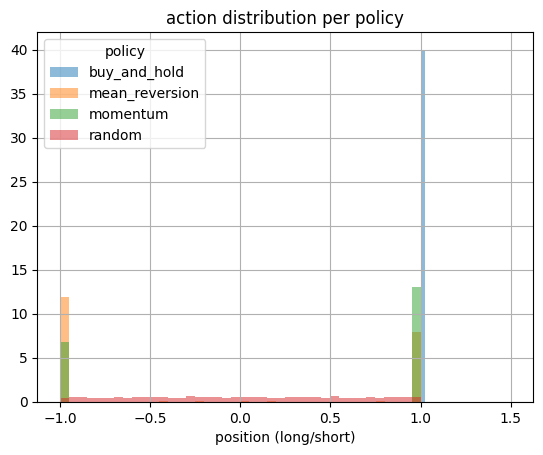

In [4]:
for policy, grp in ds.groupby("policy"):
    grp["action"].hist(bins=40, alpha=0.5, density=True, label=policy)
plt.legend(title="policy")
plt.xlabel("position (long/short)")
plt.title("action distribution per policy")
plt.show()